In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from array import array
from os.path import join
import struct
from tqdm import tqdm

In [2]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test) 

In [3]:
input_path = './input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

In [4]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if title_text != '':
            plt.title(title_text, fontsize=15)
        index += 1

def show_image(image, title_text):
    plt.imshow(image, cmap=plt.cm.gray)
    plt.title(title_text)

In [5]:
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

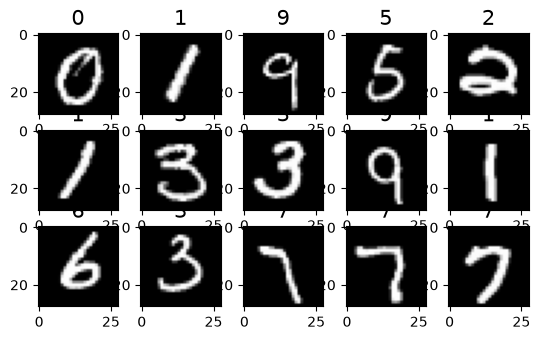

In [6]:
import random
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append(y_train[r])    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append(y_test[r])    

show_images(images_2_show, titles_2_show)

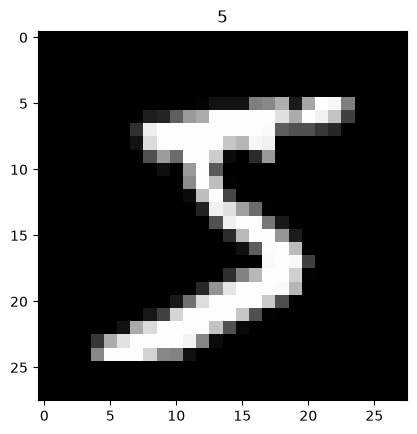

In [7]:
show_image(x_train[0],y_train[0])

In [8]:
x_train, y_train, x_test, y_test = np.array(x_train), np.array(y_train), np.array(x_test), np.array(y_test)

In [9]:
np.shape(x_train)

(60000, 28, 28)

In [10]:
np.shape(x_train[0])

(28, 28)

In [11]:
def init_params():
    w_1 = np.random.rand(10, 28*28) - 0.5
    b_1 = np.random.rand(10, 1) - 0.5
    w_2 = np.random.rand(10, 10) - 0.5
    b_2 = np.random.rand(10, 1) - 0.5
    return w_1, b_1, w_2, b_2

def relu(X):
    return np.maximum(X, 0)

def relu_deriv(X):
    return (X > 0).astype(float)

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    e = np.exp(Z)
    return e / np.sum(e, axis=0, keepdims=True)

def forward(x, w_1, b_1, w_2, b_2):
    z_1 = w_1.dot(x) + b_1
    a_1 = relu(z_1)
    z_2 = w_2.dot(a_1) + b_2
    a_2 = softmax(z_2)
    return z_1, a_1, z_2, a_2

def one_hot(y, num_classes):
    one_hot_encoding = np.zeros((y.size, num_classes))
    one_hot_encoding[np.arange(y.size), y] = 1
    return one_hot_encoding.T

def backward(x, y, w_2, a_1, a_2, z_1, z_2):
    m = y.size
    one_hot_y = one_hot(y, 10)
    dZ_2 = a_2 - one_hot_y
    dW_2 = 1/m * dZ_2.dot(a_1.T)
    db_2 = 1/m * np.sum(dZ_2, axis=1, keepdims=True)
    dZ_1 = w_2.T.dot(dZ_2) * relu_deriv(z_1)
    dW_1 = 1/m * dZ_1.dot(x.T)
    db_1 = 1/m * np.sum(dZ_1, axis=1, keepdims=True)
    return dW_1, db_1, dW_2, db_2

def update(w_1, dW_1, b_1, db_1, w_2, dW_2, b_2, db_2, alpha):
    w_1 = w_1 - alpha * dW_1
    b_1 = b_1 - alpha * db_1
    w_2 = w_2 - alpha * dW_2
    b_2 = b_2 - alpha * db_2
    return w_1, b_1, w_2, b_2

In [12]:
def get_predictions(a_2):
    return np.argmax(a_2, 0)

def get_accuracy(y_pred, y):
    return np.sum(y_pred == y) / y.size

def gradient_descent(X, y, iterations, alpha):
    w_1, b_1, w_2, b_2 = init_params()
    acc = 0
    pbar = tqdm(range(iterations), desc="training")
    for i in pbar:
        z_1, a_1, z_2, a_2 = forward(x=X, w_1=w_1, b_1=b_1, w_2=w_2, b_2=b_2)
        dW_1, db_1, dW_2, db_2 = backward(x=X, y=y, w_2=w_2, a_1=a_1, a_2=a_2, z_1=z_1, z_2=z_2)
        w_1, b_1, w_2, b_2 = update(w_1=w_1, dW_1=dW_1, b_1=b_1, db_1=db_1, w_2=w_2, dW_2=dW_2, b_2=b_2, db_2=db_2, alpha=alpha)

        acc = get_accuracy(get_predictions(a_2), y)
        loss = -np.mean(np.log(a_2[y, np.arange(y.size)] + 1e-9))
        pbar.set_postfix(acc=f"{acc:.4f}", loss=f"{loss:.3f}")
    return w_1, b_1, w_2, b_2

In [13]:
X_train_flattened = x_train.reshape(x_train.shape[0], -1).T / 255.0
X_test_flattened = x_test.reshape(x_test.shape[0], -1).T / 255.0

w_1, b_1, w_2, b_2 = gradient_descent(X_train_flattened, y_train, 500, 0.10)
# print(w_1, b_1, w_2, b_2)

_, _, _, test_forward = forward(x=X_test_flattened, w_1=w_1, b_1=b_1, w_2=w_2, b_2=b_2)
acc = get_accuracy(get_predictions(test_forward), y_test)
loss = -np.mean(np.log(test_forward[y_test, np.arange(y_test.size)] + 1e-9))
print(f"Test accuracy: {acc:.3f}, loss: {loss:.3f}")

training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [01:28<00:00,  5.66it/s, acc=0.8213, loss=0.569]

Test accuracy: 0.830, loss: 0.552
